# Final figures and tables

Loads saved results and renders the publication figures and tables. No training.

All figures are written as vector PDF to `results/final_figures/`, tables to
`results/final_tables/`.

## Provenance — which file backs which panel

Two environments exist in this project and they are **not** interchangeable
(`results/parity_report.md`: early stopping is a discrete choice, so a torch
version change can shift RMSE by far more than float noise).

| | environment | torch |
|---|---|---|
| notebooks 06–09 | base | 2.7.1 |
| notebooks 10–11 + the MLP re-run | PyG env | 2.13 |

| figure | source file(s) | environment |
|---|---|---|
| Fig 1 | none (schematic) | — |
| Fig 2a | `features.npz` (computed) | — |
| Fig 2b,c | `preds_mlp_pygenv/preds_{B,Bc}_random_seed42.npz` | PyG |
| Fig 3 | `metrics_mlp_pygenv.csv`, bootstrap from `preds_mlp_pygenv/` | PyG |
| Fig 4 | `preds_mlp_pygenv/preds_Bc_{textrap,coldsol}_seed*.npz` | PyG |
| Fig 5 | notebook 08 stored outputs (see note below) | base |
| Fig 6 | `metrics_gine.csv`, `metrics_coldsol_repeat.csv` | PyG |
| Fig S1 | `metrics_temperature_sparsity.csv` | base |

**Every direct comparison inside a single panel uses one environment.** Fig 5
(base) and Fig 6 (PyG) both concern repeated cold-solute holdouts but are never
overlaid — Fig 5 compares A vs Bc, Fig 6 compares MLP vs GINE.

**Note on Fig 5.** Notebook 08 wrote `metrics_repeated_coldsol.csv`, which was
never committed and is absent from this checkout. Its per-partition values are
taken from notebook 08's stored cell outputs and are hard-coded below with that
provenance stated, rather than silently re-running a different configuration.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
RES = ROOT / "results"
FIGS = RES / "final_figures"; FIGS.mkdir(parents=True, exist_ok=True)
TABS = RES / "final_tables";  TABS.mkdir(parents=True, exist_ok=True)

# Publication defaults: vector text (TrueType), journal-column sizing.
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.1,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
COL1, COL2 = 3.4, 7.0          # single- and double-column widths (inches)
C_DIRECT, C_PHYS, C_GREY = "#3B6EA5", "#B5453C", "#8A8A8A"

def save(fig, name):
    fig.savefig(FIGS / f"{name}.pdf")
    fig.savefig(FIGS / f"{name}.png", dpi=200)   # optional preview
    print(f"wrote {name}.pdf")

T_REF = 298.15
feats = np.load(RES / "features.npz", allow_pickle=True)
T_arr = feats["T"].astype(np.float64)
y_all = feats["y"].astype(np.float64)
pair_id = feats["pair_id"]
z_all = 1.0 / T_REF - 1.0 / T_arr
print(f"loaded {len(y_all):,} measurements")

loaded 100,983 measurements


## Figure 1 — study design (conceptual)

wrote Fig1_study_design.pdf


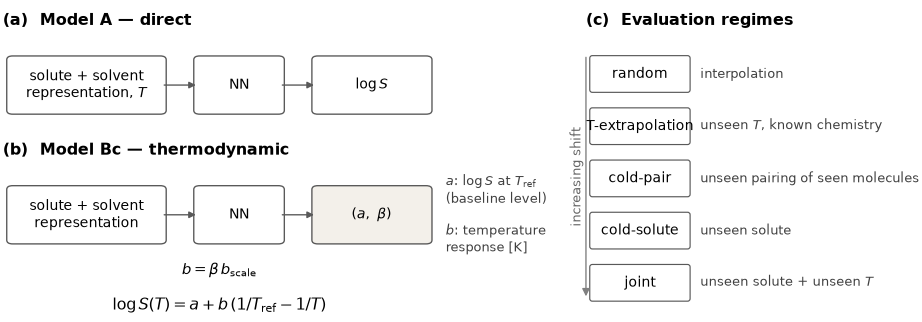

In [2]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(COL2, 2.5),
                              gridspec_kw={"width_ratios": [1.55, 1]})

def box(a, x, y, w, h, text, fc="white", ec="0.35"):
    a.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012",
                               fc=fc, ec=ec, lw=0.7))
    a.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=7.2)

def arrow(a, x1, y1, x2, y2):
    a.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                mutation_scale=7, lw=0.7, color="0.35"))

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
# Model A
ax.text(0.0, 0.93, "(a)  Model A — direct", fontsize=8, weight="bold", ha="left")
box(ax, 0.02, 0.66, 0.30, 0.16, "solute + solvent\nrepresentation, $T$")
box(ax, 0.40, 0.66, 0.16, 0.16, "NN")
box(ax, 0.64, 0.66, 0.22, 0.16, "$\\log S$")
arrow(ax, 0.32, 0.74, 0.40, 0.74); arrow(ax, 0.56, 0.74, 0.64, 0.74)

# Model Bc
ax.text(0.0, 0.52, "(b)  Model Bc — thermodynamic", fontsize=8, weight="bold", ha="left")
box(ax, 0.02, 0.25, 0.30, 0.16, "solute + solvent\nrepresentation")
box(ax, 0.40, 0.25, 0.16, 0.16, "NN")
box(ax, 0.64, 0.25, 0.22, 0.16, r"$(a,\ \beta)$", fc="#F3F0EA")
arrow(ax, 0.32, 0.33, 0.40, 0.33); arrow(ax, 0.56, 0.33, 0.64, 0.33)
ax.text(0.44, 0.14, r"$b=\beta\, b_{\mathrm{scale}}$", fontsize=7.5, ha="center")
ax.text(0.44, 0.03, r"$\log S(T) = a + b\,(1/T_{\mathrm{ref}} - 1/T)$",
        fontsize=8, ha="center")
ax.text(0.90, 0.33, "$a$: $\\log S$ at $T_{\\mathrm{ref}}$\n(baseline level)\n\n"
                    "$b$: temperature\nresponse [K]",
        fontsize=6.8, va="center", ha="left", color="0.25")

# generalization regimes
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis("off")
ax2.text(0.0, 0.93, "(c)  Evaluation regimes", fontsize=8, weight="bold", ha="left")
regimes = [("random", "interpolation"),
           ("T-extrapolation", "unseen $T$, known chemistry"),
           ("cold-pair", "unseen pairing of seen molecules"),
           ("cold-solute", "unseen solute"),
           ("joint", "unseen solute $+$ unseen $T$")]
for i, (name, desc) in enumerate(regimes):
    yy = 0.78 - i * 0.165
    ax2.add_patch(FancyBboxPatch((0.02, yy - 0.055), 0.30, 0.10,
                                 boxstyle="round,pad=0.008", fc="white", ec="0.35", lw=0.6))
    ax2.text(0.17, yy - 0.005, name, ha="center", va="center", fontsize=7)
    ax2.text(0.36, yy - 0.005, desc, ha="left", va="center", fontsize=6.8, color="0.25")
ax2.annotate("", xy=(0.0, 0.06), xytext=(0.0, 0.84),
             arrowprops=dict(arrowstyle="-|>", lw=0.7, color="0.5"))
ax2.text(-0.03, 0.45, "increasing shift", rotation=90, fontsize=6.5,
         va="center", ha="center", color="0.4")

fig.tight_layout()
save(fig, "Fig1_study_design")
plt.show()

## Figure 2 — conditioning failure and slope recovery

In [3]:
# Panel a: |z| is tiny, so the raw slope head gets a ~1e-4 gradient signal.
b_scale = json.loads((RES / "b_scale.json").read_text())["splits"]["random"]["b_scale"]
absz = np.abs(z_all)

# Empirical slopes come from the full-data per-pair Van't Hoff fits
# (results/stage5_pair_fits.csv, >=3 rows and >=3 distinct T), joined onto the
# pairs present in the split's test set. This is the definition notebook 07 used
# -- fitting instead on each pair's handful of random-split test rows would leave
# only ~720 pairs and is a different quantity.
from prepare_b_scale import per_pair_slopes
_b, _pid, _ = per_pair_slopes(T_arr, y_all, pair_id)      # full-data per-pair fits
EMP_B = pd.Series(_b, index=_pid, name="b_m")

def slope_pairs(fname):
    d = np.load(RES / "preds_mlp_pygenv" / fname, allow_pickle=True)
    pred = pd.DataFrame({"pair_id": d["pair_id"], "b_pred": d["slope_b"]}) \
             .groupby("pair_id")["b_pred"].first()
    j = pd.concat([EMP_B.rename("b_emp"), pred], axis=1, join="inner").dropna()
    return j.reset_index()

sb = slope_pairs("preds_B_random_seed42.npz")
sc = slope_pairs("preds_Bc_random_seed42.npz")
for nm, d in [("B", sb), ("Bc", sc)]:
    r = np.corrcoef(d.b_emp, d.b_pred)[0, 1]
    print(f"{nm:>3}: n={len(d):4d}  Pearson r={r:.3f}  MAE={np.abs(d.b_pred-d.b_emp).mean():.0f} K")

  B: n=6490  Pearson r=0.278  MAE=555 K
 Bc: n=6490  Pearson r=0.721  MAE=399 K


wrote Fig2_conditioning_slope_recovery.pdf


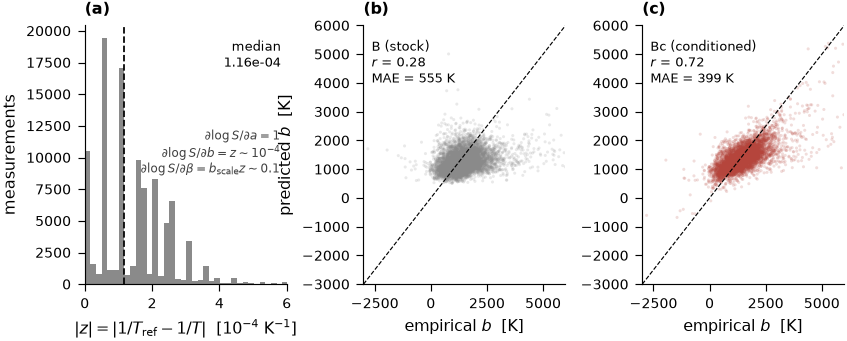

In [4]:
fig = plt.figure(figsize=(COL2, 2.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.38)

# (a) magnitude of z and the resulting gradient scales
axa = fig.add_subplot(gs[0])
axa.hist(absz * 1e4, bins=60, color=C_GREY, edgecolor="none")
axa.axvline(np.median(absz) * 1e4, color="k", lw=0.9, ls="--")
axa.set_xlabel(r"$|z| = |1/T_{\mathrm{ref}} - 1/T|$  [$10^{-4}\ \mathrm{K}^{-1}$]")
axa.set_ylabel("measurements")
axa.set_xlim(0, 6)
axa.text(0.97, 0.95, f"median\n{np.median(absz):.2e}", transform=axa.transAxes,
         ha="right", va="top", fontsize=6.8)
axa.text(0.97, 0.60,
         "$\\partial\\log S/\\partial a = 1$\n"
         "$\\partial\\log S/\\partial b = z \\sim 10^{-4}$\n"
         "$\\partial\\log S/\\partial \\beta = b_{\\mathrm{scale}}z \\sim 0.1$",
         transform=axa.transAxes, ha="right", va="top", fontsize=6.3, color="0.25")
axa.set_title("(a)", loc="left", fontsize=8, weight="bold")

lim = (-3000, 6000)
for k, (nm, d, col) in enumerate([("B (stock)", sb, C_GREY), ("Bc (conditioned)", sc, C_PHYS)]):
    ax = fig.add_subplot(gs[k + 1])
    ax.scatter(d.b_emp, d.b_pred, s=2.5, alpha=0.18, color=col, edgecolors="none", rasterized=True)
    ax.plot(lim, lim, color="k", lw=0.6, ls="--")
    ax.set_xlim(*lim); ax.set_ylim(*lim)
    ax.set_xlabel("empirical $b$  [K]")
    if k == 0:
        ax.set_ylabel("predicted $b$  [K]")
    r = np.corrcoef(d.b_emp, d.b_pred)[0, 1]
    mae = np.abs(d.b_pred - d.b_emp).mean()
    ax.text(0.04, 0.95, f"{nm}\n$r$ = {r:.2f}\nMAE = {mae:.0f} K",
            transform=ax.transAxes, va="top", fontsize=6.8)
    ax.set_title(f"({'bc'[k]})", loc="left", fontsize=8, weight="bold")

save(fig, "Fig2_conditioning_slope_recovery")
plt.show()

## Figure 3 — where thermodynamic bias helps

A vs Bc across evaluation regimes, all from the same environment. The
T-extrapolation comparison is annotated with a paired cluster bootstrap
(resampling pairs, seed-ensembled) computed from the same predictions.

In [5]:
mlp = pd.read_csv(RES / "metrics_mlp_pygenv.csv").drop_duplicates(
    ["model", "split", "seed"], keep="last")
ORDER = ["random", "textrap", "coldsol", "coldpair", "coldsol_textrap"]
NICE = {"random": "random", "textrap": "T-extrap", "coldsol": "cold-solute",
        "coldpair": "cold-pair", "coldsol_textrap": "joint\n(cold-sol + T-extrap)"}

# metrics_mlp_pygenv.csv labels its models "A_MLP" / "Bc_MLP".
def stat(split, model):
    v = mlp[(mlp.split == split) & (mlp.model == f"{model}_MLP")]["test_rmse"]
    return v.mean(), v.std()

def bootstrap_pair(split, n_boot=2000, seed=0):
    # Paired cluster bootstrap over pairs; predictions ensembled across seeds.
    def stack(kind):
        acc, idx, pid, yt = None, None, None, None
        for s in [42, 123, 456]:
            d = np.load(RES / "preds_mlp_pygenv" / f"preds_{kind}_{split}_seed{s}.npz",
                        allow_pickle=True)
            if acc is None:
                acc = np.zeros_like(d["y_pred"], dtype=float); idx = d["test_idx"]
                pid = d["pair_id"]; yt = d["y_true"]
            acc += d["y_pred"]
        return acc / 3, pid, yt
    yA, pid_, yt = stack("A"); yB, _, _ = stack("Bc")
    df = pd.DataFrame({"pair": pid_, "eA": (yA - yt) ** 2, "eB": (yB - yt) ** 2})
    groups = {p: g.index.values for p, g in df.groupby("pair")}
    keys = np.array(list(groups))
    rng = np.random.default_rng(seed)
    out = np.empty(n_boot)
    for i in range(n_boot):
        rows = np.concatenate([groups[p] for p in rng.choice(keys, len(keys), replace=True)])
        out[i] = np.sqrt(df.eB.values[rows].mean()) - np.sqrt(df.eA.values[rows].mean())
    obs = np.sqrt(df.eB.mean()) - np.sqrt(df.eA.mean())
    return obs, np.percentile(out, [2.5, 97.5])

obs_t, ci_t = bootstrap_pair("textrap")
print(f"T-extrap  Bc - A = {obs_t:+.4f}   95% CI [{ci_t[0]:+.4f}, {ci_t[1]:+.4f}]")

T-extrap  Bc - A = -0.0156   95% CI [-0.0184, -0.0128]


wrote Fig3_distribution_shift_performance.pdf


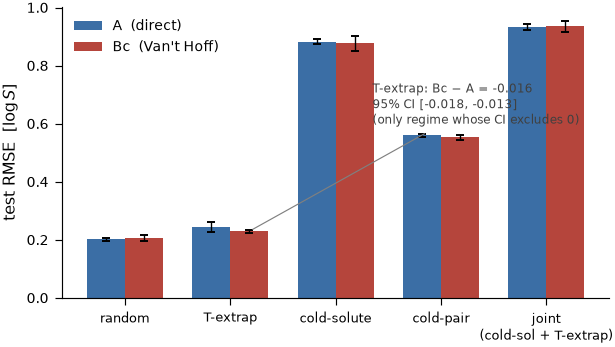

In [6]:
fig, ax = plt.subplots(figsize=(COL2 * 0.72, 2.7))
x = np.arange(len(ORDER)); w = 0.36
for k, (model, col, lab) in enumerate([("A", C_DIRECT, "A  (direct)"),
                                       ("Bc", C_PHYS, "Bc  (Van't Hoff)")]):
    mu = [stat(s, model)[0] for s in ORDER]
    sd = [stat(s, model)[1] for s in ORDER]
    ax.bar(x + (k - 0.5) * w, mu, w, yerr=sd, capsize=2, label=lab,
           color=col, edgecolor="none", error_kw=dict(lw=0.7))
ax.set_xticks(x); ax.set_xticklabels([NICE[s] for s in ORDER], fontsize=6.8)
ax.set_ylabel("test RMSE  [$\\log S$]")
ax.legend(frameon=False, loc="upper left")
ax.annotate(f"T-extrap: Bc $-$ A = {obs_t:+.3f}\n"
            f"95% CI [{ci_t[0]:+.3f}, {ci_t[1]:+.3f}]\n"
            f"(only regime whose CI excludes 0)",
            xy=(1.18, stat("textrap", "Bc")[0]), xytext=(2.35, 0.60),
            fontsize=6.4, color="0.25", ha="left",
            arrowprops=dict(arrowstyle="-", lw=0.6, color="0.5"))
save(fig, "Fig3_distribution_shift_performance")
plt.show()

## Figure 4 — why unseen chemistry fails

For each held-out pair the error decomposes exactly as
$\varepsilon(z) = \Delta a + \Delta b\, z$. Because $|z| \le 10^{-3}$, a large
slope error contributes far less than a modest intercept error.

In [7]:
def decompose(split):
    # Empirical (a, b) fitted on each pair's own test rows, vs the model's (a, b).
    d0 = np.load(RES / "preds_mlp_pygenv" / f"preds_Bc_{split}_seed42.npz", allow_pickle=True)
    df = pd.DataFrame({"pair_id": d0["pair_id"], "z": 1/T_REF - 1/d0["T"], "y": d0["y_true"]})
    ap, bp = {}, {}
    for s in [42, 123, 456]:
        d = np.load(RES / "preds_mlp_pygenv" / f"preds_Bc_{split}_seed{s}.npz", allow_pickle=True)
        g = pd.DataFrame({"p": d["pair_id"], "a": d["slope_a"], "b": d["slope_b"]}).groupby("p").first()
        for p, r in g.iterrows():
            ap.setdefault(p, []).append(r.a); bp.setdefault(p, []).append(r.b)
    da_l, dbz_l = [], []
    for pid, g in df.groupby("pair_id"):
        if len(g) < 3 or g["z"].nunique() < 3:
            continue
        zc = g["z"] - g["z"].mean(); den = float((zc**2).sum())
        if den <= 0:
            continue
        b_t = float((zc * (g["y"] - g["y"].mean())).sum() / den)
        a_t = float(g["y"].mean() - b_t * g["z"].mean())
        da = np.mean(ap[pid]) - a_t
        db = np.mean(bp[pid]) - b_t
        da_l.extend([abs(da)] * len(g))                    # row-level, as notebook 07
        dbz_l.extend(np.abs(db * g["z"].to_numpy()).tolist())
    return np.array(da_l), np.array(dbz_l)

dec = {s: decompose(s) for s in ["textrap", "coldsol"]}
for s, (da, dbz) in dec.items():
    print(f"{s:8s} n={len(da):4d}  median |da|={np.median(da):.4f}  "
          f"median |db*z|={np.median(dbz):.4f}  ratio={np.median(da)/np.median(dbz):.1f}x")

textrap  n=14449  median |da|=0.0796  median |db*z|=0.0733  ratio=1.1x
coldsol  n=10423  median |da|=0.5096  median |db*z|=0.0354  ratio=14.4x


wrote Fig4_error_decomposition.pdf


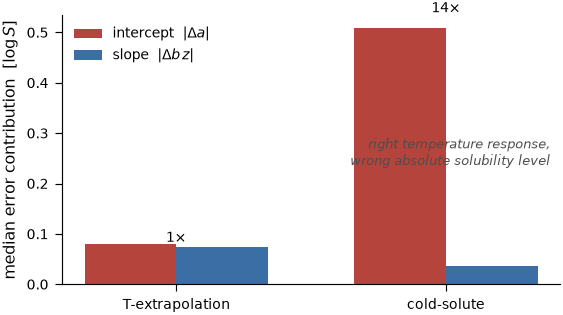

In [8]:
fig, ax = plt.subplots(figsize=(COL1 * 1.35, 2.5))
labels, inter, slope = [], [], []
for s, nice in [("textrap", "T-extrapolation"), ("coldsol", "cold-solute")]:
    da, dbz = dec[s]
    labels.append(nice); inter.append(np.median(da)); slope.append(np.median(dbz))

x = np.arange(len(labels)); w = 0.34
ax.bar(x - w/2, inter, w, label=r"intercept  $|\Delta a|$", color=C_PHYS, edgecolor="none")
ax.bar(x + w/2, slope, w, label=r"slope  $|\Delta b\, z|$", color=C_DIRECT, edgecolor="none")
for i in range(len(labels)):
    ax.text(x[i], max(inter[i], slope[i]) * 1.06, f"{inter[i]/slope[i]:.0f}$\\times$",
            ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("median error contribution  [$\\log S$]")
ax.legend(frameon=False, loc="upper left")
ax.text(0.98, 0.55, "right temperature response,\nwrong absolute solubility level",
        transform=ax.transAxes, ha="right", va="top", fontsize=6.6, color="0.3", style="italic")
save(fig, "Fig4_error_decomposition")
plt.show()

## Figure 5 — repeated chemistry-OOD holdouts (methodological)

Values from notebook 08's stored outputs (`metrics_repeated_coldsol.csv` is not
present in this checkout — see the provenance note at the top).

wrote Fig5_repeated_coldsol_holdouts.pdf


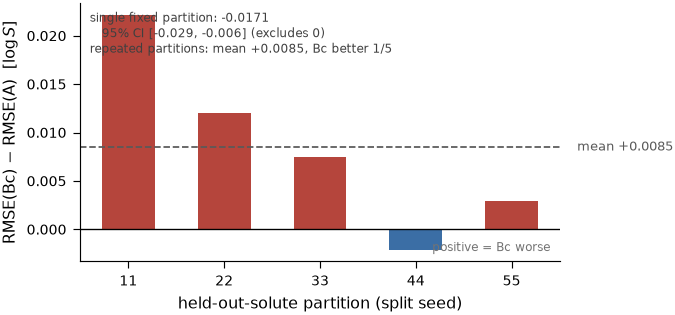

In [9]:
# Notebook 08, repeated cold-solute holdouts (base env, 3 model seeds per partition).
nb08 = pd.DataFrame({
    "split_seed": [11, 22, 33, 44, 55],
    "A":  [0.8611, 0.9981, 0.8280, 0.9044, 0.8663],
    "Bc": [0.8833, 1.0101, 0.8355, 0.9023, 0.8692],
})
nb08["diff"] = nb08.Bc - nb08.A
FIXED_OBS, FIXED_CI = -0.0171, (-0.0294, -0.0057)   # notebook 07, single partition

fig, ax = plt.subplots(figsize=(COL1 * 1.3, 2.4))
x = np.arange(len(nb08))
cols = [C_PHYS if v > 0 else C_DIRECT for v in nb08["diff"]]
ax.bar(x, nb08["diff"], 0.55, color=cols, edgecolor="none")
ax.axhline(0, color="k", lw=0.7)
m = nb08["diff"].mean()
ax.axhline(m, color="0.35", lw=0.9, ls="--")
ax.text(len(nb08) - 0.4, m, f"  mean {m:+.4f}", va="center", fontsize=6.8, color="0.35")
ax.set_xticks(x); ax.set_xticklabels([f"{s}" for s in nb08.split_seed])
ax.set_xlabel("held-out-solute partition (split seed)")
ax.set_ylabel(r"RMSE(Bc) $-$ RMSE(A)  [$\log S$]")
ax.text(0.02, 0.97,
        f"single fixed partition: {FIXED_OBS:+.4f}\n"
        f"   95% CI [{FIXED_CI[0]:+.3f}, {FIXED_CI[1]:+.3f}] (excludes 0)\n"
        f"repeated partitions: mean {m:+.4f}, Bc better {int((nb08['diff']<0).sum())}/5",
        transform=ax.transAxes, va="top", fontsize=6.4, color="0.25")
ax.text(0.98, 0.04, "positive = Bc worse", transform=ax.transAxes,
        ha="right", fontsize=6.3, color="0.45")
save(fig, "Fig5_repeated_coldsol_holdouts")
plt.show()

## Figure 6 — representation stress test (GINE)

wrote Fig6_gine_representation.pdf


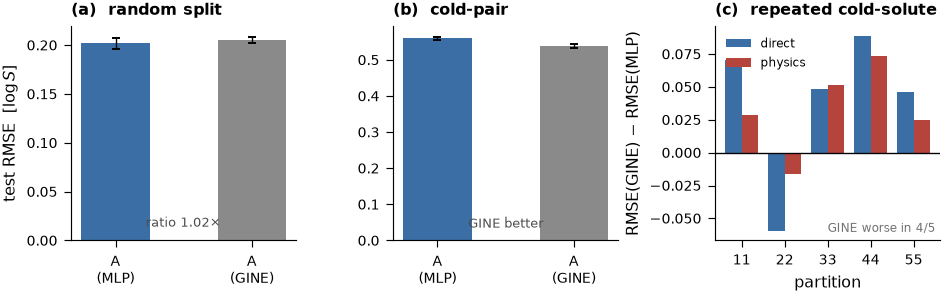

In [10]:
gine = pd.read_csv(RES / "metrics_gine.csv").drop_duplicates(["model","split","seed"], keep="last")
rep = pd.read_csv(RES / "metrics_coldsol_repeat.csv").drop_duplicates(
    ["model","split_seed","model_seed"], keep="last")
rep_mean = rep.groupby(["split_seed","model"])["test_rmse"].mean().unstack("model")

def gstat(split, model):
    # GINE runs are labelled A_GINE/Bc_GINE; the MLP arm A_MLP/Bc_MLP.
    src = gine if model.endswith("GINE") else mlp
    v = src[(src.split == split) & (src.model == model)]["test_rmse"]
    return v.mean(), v.std()

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.3))

# (a) random-split parity
ax = axes[0]
vals = [gstat("random", m) for m in ["A_MLP", "A_GINE"]]
ax.bar([0, 1], [v[0] for v in vals], 0.5, yerr=[v[1] for v in vals], capsize=2,
       color=[C_DIRECT, C_GREY], edgecolor="none", error_kw=dict(lw=0.7))
ax.set_xticks([0, 1]); ax.set_xticklabels(["A\n(MLP)", "A\n(GINE)"], fontsize=7)
ax.set_ylabel("test RMSE  [$\\log S$]")
ax.set_title("(a)  random split", loc="left", fontsize=8, weight="bold")
ax.text(0.5, 0.06, f"ratio {vals[1][0]/vals[0][0]:.2f}$\\times$", transform=ax.transAxes,
        ha="center", fontsize=6.8, color="0.3")

# (b) cold-pair
ax = axes[1]
vals = [gstat("coldpair", m) for m in ["A_MLP", "A_GINE"]]
ax.bar([0, 1], [v[0] for v in vals], 0.5, yerr=[v[1] for v in vals], capsize=2,
       color=[C_DIRECT, C_GREY], edgecolor="none", error_kw=dict(lw=0.7))
ax.set_xticks([0, 1]); ax.set_xticklabels(["A\n(MLP)", "A\n(GINE)"], fontsize=7)
ax.set_title("(b)  cold-pair", loc="left", fontsize=8, weight="bold")
ax.text(0.5, 0.06, "GINE better", transform=ax.transAxes, ha="center",
        fontsize=6.8, color="0.3")

# (c) repeated cold-solute representation gap
ax = axes[2]
x = np.arange(len(rep_mean)); w = 0.38
dA = (rep_mean["A_GINE"] - rep_mean["A_MLP"]).to_numpy()
dB = (rep_mean["Bc_GINE"] - rep_mean["Bc_MLP"]).to_numpy()
ax.bar(x - w/2, dA, w, label="direct", color=C_DIRECT, edgecolor="none")
ax.bar(x + w/2, dB, w, label="physics", color=C_PHYS, edgecolor="none")
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(rep_mean.index, fontsize=7)
ax.set_xlabel("partition")
ax.set_ylabel("RMSE(GINE) $-$ RMSE(MLP)")
ax.legend(frameon=False, fontsize=6.3, loc="upper left")
ax.set_title("(c)  repeated cold-solute", loc="left", fontsize=8, weight="bold")
ax.text(0.98, 0.04, f"GINE worse in {int((dA>0).sum())}/5", transform=ax.transAxes,
        ha="right", fontsize=6.3, color="0.45")

fig.tight_layout()
save(fig, "Fig6_gine_representation")
plt.show()

## Figure S1 — temperature sparsity

wrote FigS1_temperature_sparsity.pdf


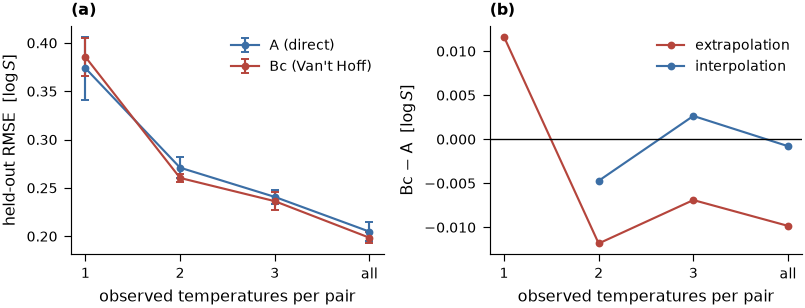

In [11]:
sp = pd.read_csv(RES / "metrics_temperature_sparsity.csv").drop_duplicates(
    ["model","n_T","sample_seed","model_seed"], keep="last")
order = ["1", "2", "3", "all"]

fig, axes = plt.subplots(1, 2, figsize=(COL2 * 0.85, 2.4))
x = np.arange(len(order))
ax = axes[0]
for m, col, lab in [("A", C_DIRECT, "A (direct)"), ("Bc", C_PHYS, "Bc (Van't Hoff)")]:
    mu = [sp[(sp.n_T == n) & (sp.model == m)]["test_rmse"].mean() for n in order]
    sd = [sp[(sp.n_T == n) & (sp.model == m)]["test_rmse"].std() for n in order]
    ax.errorbar(x, mu, yerr=sd, marker="o", ms=3, capsize=2, label=lab, color=col)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_xlabel("observed temperatures per pair")
ax.set_ylabel("held-out RMSE  [$\\log S$]")
ax.legend(frameon=False)
ax.set_title("(a)", loc="left", fontsize=8, weight="bold")

ax = axes[1]
for metric, col, lab in [("rmse_extrap", C_PHYS, "extrapolation"),
                         ("rmse_interp", C_DIRECT, "interpolation")]:
    d = [sp[(sp.n_T == n) & (sp.model == "Bc")][metric].mean() -
         sp[(sp.n_T == n) & (sp.model == "A")][metric].mean() for n in order]
    ax.plot(x, d, marker="o", ms=3, label=lab, color=col)
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_xlabel("observed temperatures per pair")
ax.set_ylabel(r"Bc $-$ A  [$\log S$]")
ax.legend(frameon=False)
ax.set_title("(b)", loc="left", fontsize=8, weight="bold")
fig.tight_layout()
save(fig, "FigS1_temperature_sparsity")
plt.show()

## Tables

In [12]:
# Table 1 — dataset splits
raw = pd.read_csv(ROOT / "data" / "BigSolDBv2.0.csv").dropna(subset=["LogS(mol/L)"]).reset_index(drop=True)
sol_id = pd.factorize(raw["SMILES_Solute"].astype(str))[0]
slv_id = pd.factorize(raw["SMILES_Solvent"].astype(str))[0]
sp_all = np.load(RES / "splits.npz"); sp_j = np.load(RES / "splits_joint.npz")

HELD = {"random": "nothing (measurement-level)", "textrap": "upper 25% of each pair's T range",
        "coldsol": "solutes", "coldpair": "solute-solvent pairs", "coldsolv": "solvents",
        "coldsol_textrap": "solutes, scored on their upper-T rows"}
rows = []
for s in ["random", "textrap", "coldsol", "coldpair", "coldsolv", "coldsol_textrap"]:
    src = sp_j if s == "coldsol_textrap" else sp_all
    tr, va, te = src[f"{s}_train"], src[f"{s}_val"], src[f"{s}_test"]
    rows.append({"split": s, "train_rows": len(tr), "val_rows": len(va), "test_rows": len(te),
                 "test_solutes": len(np.unique(sol_id[te])), "test_solvents": len(np.unique(slv_id[te])),
                 "test_pairs": len(np.unique(pair_id[te])), "held_out": HELD[s]})
t1 = pd.DataFrame(rows)
t1.to_csv(TABS / "Table1_dataset_splits.csv", index=False)
t1

,split,train_rows,val_rows,test_rows,test_solutes,test_solvents,test_pairs,held_out
0,random,80786,10098,10099,1305,69,6527,nothing (measurement-level)
1,textrap,67902,7385,25696,1356,70,10301,upper 25% of each pair's T range
2,coldsol,81610,8937,10436,145,64,1067,solutes
3,coldpair,80806,10187,9990,710,63,1085,solute-solvent pairs
4,coldsolv,77981,11262,11740,752,7,1226,solvents
5,coldsol_textrap,81040,8806,2820,135,60,1106,"solutes, scored on their upper-T rows"


In [13]:
# Table 2 — main benchmark. Two environments, explicitly labelled; never mixed
# inside a single comparison.
stage4 = pd.read_csv(RES / "metrics_stage4.csv")     # A / D / B, base env
rows = []
for split in ["random", "textrap", "coldsol", "coldpair", "coldsolv", "coldsol_textrap"]:
    for model in ["A", "D", "B", "Bc"]:
        # authoritative A/Bc = PyG env (complete, same-environment, includes joint)
        if model in ("A", "Bc") and split in mlp.split.values:
            v = mlp[(mlp.split == split) & (mlp.model == f"{model}_MLP")]["test_rmse"]
            env, src = "PyG (torch 2.13)", "metrics_mlp_pygenv.csv"
        elif model in ("D", "B") and split in stage4.split.values:
            v = stage4[(stage4.split == split) & (stage4.model == model)]["test_rmse"]
            env, src = "base (torch 2.7.1)", "metrics_stage4.csv"
        else:
            continue
        if not len(v):
            continue
        rows.append({"split": split, "model": model, "n_seeds": len(v),
                     "rmse_mean": round(v.mean(), 4), "rmse_std": round(v.std(), 4),
                     "environment": env, "source_file": src,
                     "authoritative_for": "A vs Bc comparison" if model in ("A", "Bc")
                                          else "historical control only"})
t2 = pd.DataFrame(rows)
t2.to_csv(TABS / "Table2_main_benchmark.csv", index=False)
t2.head(12)

,split,model,n_seeds,rmse_mean,rmse_std,environment,source_file,authoritative_for
0,random,A,3,0.2018,0.0056,PyG (torch 2.13),metrics_mlp_pygenv.csv,A vs Bc comparison
1,random,D,3,0.2203,0.0078,base (torch 2.7.1),metrics_stage4.csv,historical control only
2,random,B,3,0.2584,0.0234,base (torch 2.7.1),metrics_stage4.csv,historical control only
3,random,Bc,3,0.2058,0.0097,PyG (torch 2.13),metrics_mlp_pygenv.csv,A vs Bc comparison
4,textrap,A,3,0.2443,0.0170,PyG (torch 2.13),metrics_mlp_pygenv.csv,A vs Bc comparison
5,textrap,D,3,0.2401,0.0066,base (torch 2.7.1),metrics_stage4.csv,historical control only
6,textrap,B,3,0.3073,0.0279,base (torch 2.7.1),metrics_stage4.csv,historical control only
7,textrap,Bc,3,0.2295,0.0048,PyG (torch 2.13),metrics_mlp_pygenv.csv,A vs Bc comparison
8,coldsol,A,3,0.8825,0.0096,PyG (torch 2.13),metrics_mlp_pygenv.csv,A vs Bc comparison
9,coldsol,D,3,0.9003,0.0153,base (torch 2.7.1),metrics_stage4.csv,historical control only


In [14]:
# Table 3 — mechanism and robustness summary
# Per-pair Van't Hoff fit quality, computed inline (same rule as
# scripts/prepare_b_scale.per_pair_slopes: >=3 rows and >=3 distinct T).
_df = pd.DataFrame({"pair_id": pair_id, "z": z_all, "y": y_all})
_r2, _res = [], []
for _p, _g in _df.groupby("pair_id"):
    if len(_g) < 3 or _g["z"].nunique() < 3:
        continue
    _zc = _g["z"] - _g["z"].mean(); _den = float((_zc ** 2).sum())
    if _den <= 0:
        continue
    _yc = _g["y"] - _g["y"].mean()
    _b = float((_zc * _yc).sum() / _den)
    _rr = _yc - _b * _zc
    _sst = float((_yc ** 2).sum())
    _r2.append(1.0 - float((_rr ** 2).sum()) / _sst if _sst > 0 else np.nan)
    _res.append(float(np.sqrt((_rr ** 2).mean())))
fits = pd.DataFrame({"r2": _r2, "rmse": _res})
rB = np.corrcoef(sb.b_emp, sb.b_pred)[0, 1]; mB = np.abs(sb.b_pred - sb.b_emp).mean()
rC = np.corrcoef(sc.b_emp, sc.b_pred)[0, 1]; mC = np.abs(sc.b_pred - sc.b_emp).mean()
da_c, dbz_c = dec["coldsol"]
dA_rep = (rep_mean["A_GINE"] - rep_mean["A_MLP"])

t3 = pd.DataFrame([
 ("Van't Hoff fit quality", "median per-pair R^2", f"{fits.r2.median():.4f}", "stage5_pair_fits.csv"),
 ("Van't Hoff fit quality", "median residual RMSE [log S]", f"{fits.rmse.median():.4f}", "stage5_pair_fits.csv"),
 ("slope recovery", "B  Pearson r / MAE [K]", f"{rB:.2f} / {mB:.0f}", "preds_mlp_pygenv"),
 ("slope recovery", "Bc Pearson r / MAE [K]", f"{rC:.2f} / {mC:.0f}", "preds_mlp_pygenv"),
 ("T-extrapolation", "Bc - A [log S] (95% CI)",
  f"{obs_t:+.4f} [{ci_t[0]:+.4f}, {ci_t[1]:+.4f}]", "preds_mlp_pygenv"),
 ("cold-solute mechanism", "median |da| / |db*z| ratio",
  f"{np.median(da_c)/np.median(dbz_c):.1f}x", "preds_mlp_pygenv"),
 ("chemistry-OOD robustness", "repeated cold-solute mean Bc - A",
  f"{nb08['diff'].mean():+.4f} (Bc better 1/5)", "notebook 08 outputs"),
 ("representation", "repeated cold-solute mean GINE - MLP (direct)",
  f"{dA_rep.mean():+.4f} (GINE better {int((dA_rep<0).sum())}/5)", "metrics_coldsol_repeat.csv"),
], columns=["group", "quantity", "value", "source"])
t3.to_csv(TABS / "Table3_mechanism_robustness.csv", index=False)
t3

,group,quantity,value,source
0,Van't Hoff fit quality,median per-pair R^2,0.9965,stage5_pair_fits.csv
1,Van't Hoff fit quality,median residual RMSE [log S],0.0102,stage5_pair_fits.csv
2,slope recovery,B Pearson r / MAE [K],0.28 / 555,preds_mlp_pygenv
3,slope recovery,Bc Pearson r / MAE [K],0.72 / 399,preds_mlp_pygenv
4,T-extrapolation,Bc - A [log S] (95% CI),"-0.0156 [-0.0184, -0.0128]",preds_mlp_pygenv
5,cold-solute mechanism,median |da| / |db*z| ratio,14.4x,preds_mlp_pygenv
6,chemistry-OOD robustness,repeated cold-solute mean Bc - A,+0.0085 (Bc better 1/5),notebook 08 outputs
7,representation,repeated cold-solute mean GINE - MLP (direct),+0.0389 (GINE better 1/5),metrics_coldsol_repeat.csv


In [15]:
import os
print("final figures:")
for f in sorted(os.listdir(FIGS)):
    if f.endswith(".pdf"):
        print(f"  {f:46s} {os.path.getsize(FIGS/f)/1024:6.1f} KB")
print("\nfinal tables:")
for f in sorted(os.listdir(TABS)):
    print(f"  {f}")

final figures:
  Fig1_study_design.pdf                            27.3 KB
  Fig2_conditioning_slope_recovery.pdf             40.3 KB
  Fig3_distribution_shift_performance.pdf          22.9 KB
  Fig4_error_decomposition.pdf                     18.6 KB
  Fig5_repeated_coldsol_holdouts.pdf               21.6 KB
  Fig6_gine_representation.pdf                     24.4 KB
  FigS1_temperature_sparsity.pdf                   26.8 KB

final tables:
  Table1_dataset_splits.csv
  Table2_main_benchmark.csv
  Table3_mechanism_robustness.csv
